In [1]:
import neuscitk as ntk
import matplotlib.pyplot as plt   #plots
import numpy as np                #arrays
dataset = ntk.LabChartDataset('/Users/nisht/Documents/CockroachLab/Lab1_Demo_Data.mat')


In [2]:
page_map = {
    'Step_triangle' : list(range(1,61)),
    'Sine_chirps' : list(range(61,121)),
    'Spontaneous' : list(range(121,181))
}

dataset.organize_by_pages(page_map)

In [3]:
Step_triangles_Trials = dataset.get_page('Step_triangle')
Sine_chirps_Trials = dataset.get_page('Sine_chirps')
Spontaneous_Trials = dataset.get_page('Spontaneous')

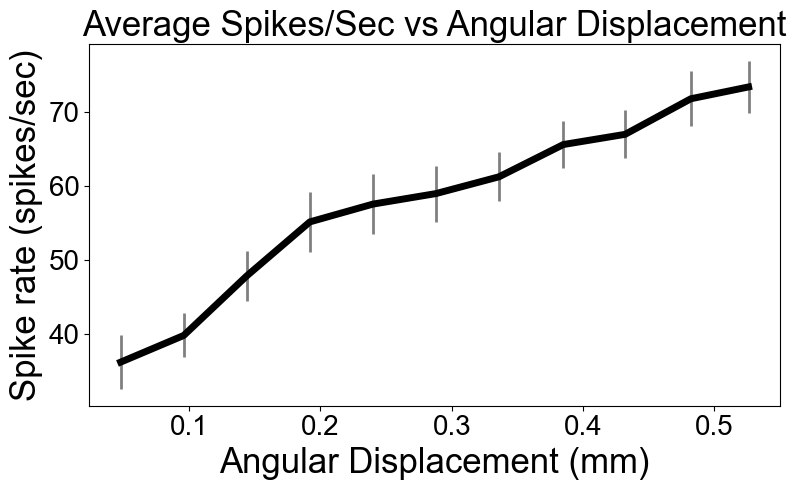

In [4]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

SR = 40000 


amplitudes = np.array([0.048, 0.096, 0.144, 0.192, 0.240,
                       0.288, 0.336, 0.385, 0.432, 0.482, 0.526])

step_windows = [
    (1.50, 1.875),
    (2.00, 2.375),
    (2.50, 2.875),
    (3.00, 3.375),
    (3.50, 3.875),
    (4.00, 4.375),
    (4.50, 4.875),
    (5.00, 5.375),
    (5.50, 5.875),
    (6.00, 6.375),
    (6.50, 6.875)
]



blocks_to_analyze = ['block_60', 'block_1', 'block_2', 'block_3', 'block_4','block_5', 'block_6', 'block_7', 'block_8', 'block_9',
                     'block_10', 'block_11', 'block_12', 'block_13', 'block_14','block_15', 'block_16', 'block_17', 'block_18', 'block_19',
                     'block_20', 'block_21', 'block_22', 'block_23', 'block_24','block_25', 'block_26', 'block_27', 'block_28', 'block_29',
                     'block_30', 'block_31', 'block_32', 'block_33', 'block_34','block_35', 'block_36', 'block_37', 'block_38', 'block_39',
                     'block_40', 'block_41', 'block_42', 'block_43', 'block_44','block_45', 'block_46', 'block_47', 'block_48', 'block_49',
                     'block_50', 'block_51', 'block_52', 'block_53', 'block_54','block_55', 'block_56', 'block_57', 'block_58', 'block_59',]
channel_index = 0


all_spike_rates = []

for block_id in blocks_to_analyze:

    data = Step_triangles_Trials[block_id][channel_index]
    time = np.arange(len(data)) / SR

    
    peaks, properties = find_peaks(data, height=0.025, distance=int(SR * 0.0005))
    spike_times = time[peaks]

   
    spike_rates= []

    for (t_start, t_end) in step_windows:
        spikes_in_window = np.sum((spike_times >= t_start) & (spike_times < t_end))
        rate = spikes_in_window / (t_end - t_start)
        spike_rates.append(rate)
   
    all_spike_rates.append(spike_rates)
    

all_spike_rates = np.array(all_spike_rates)


mean_rates = np.mean(all_spike_rates, axis=0)
sem_rates = np.std(all_spike_rates, axis=0, ddof=1) / np.sqrt(all_spike_rates.shape[0])


amplitude_mm = amplitudes 


plt.rcParams['font.family'] = 'Arial'

plt.figure(figsize=(8, 5))
plt.errorbar(amplitude_mm, mean_rates, yerr=sem_rates, fmt='-', capsize=0, color='black', ecolor='gray', linewidth=5, elinewidth=2)
ax = plt.gca()


plt.xlabel("Angular Displacement (mm)", fontsize=25)
plt.ylabel("Spike rate (spikes/sec)", fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.title("Average Spikes/Sec vs Angular Displacement", fontsize=25)
plt.tight_layout()
plt.show()

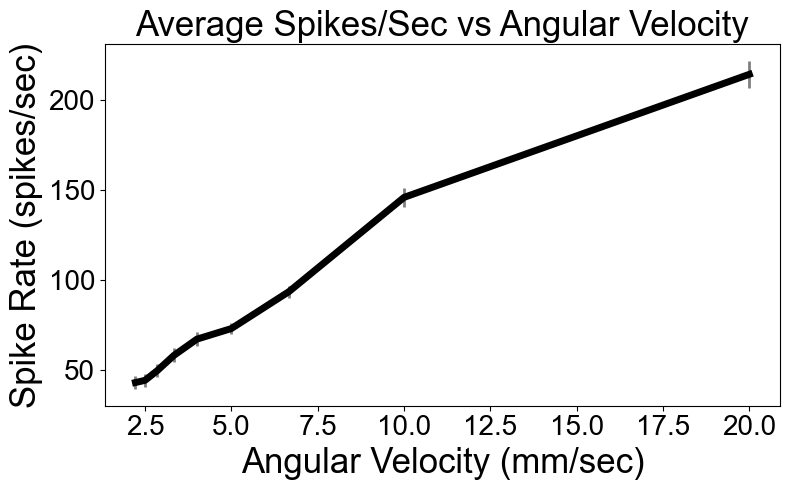

In [5]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

SR = 40000  


stim_velocity = np.array([0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5])

triangle_windows = [
    (8.00, 8.45),
    (8.75, 9.15),
    (9.50, 9.85),
    (10.25, 10.55),
    (11.0, 11.25),
    (11.75, 11.95),
    (12.50, 12.65),
    (13.25, 13.35),
    (14.00, 14.05),
]



blocks_to_analyze = ['block_60', 'block_1', 'block_2', 'block_3', 'block_4','block_5', 'block_6', 'block_7', 'block_8', 'block_9',
                     'block_10', 'block_11', 'block_12', 'block_13', 'block_14','block_15', 'block_16', 'block_17', 'block_18', 'block_19',
                     'block_20', 'block_21', 'block_22', 'block_23', 'block_24','block_25', 'block_26', 'block_27', 'block_28', 'block_29',
                     'block_30', 'block_31', 'block_32', 'block_33', 'block_34','block_35', 'block_36', 'block_37', 'block_38', 'block_39',
                     'block_40', 'block_41', 'block_42', 'block_43', 'block_44','block_45', 'block_46', 'block_47', 'block_48', 'block_49',
                     'block_50', 'block_51', 'block_52', 'block_53', 'block_54','block_55', 'block_56', 'block_57', 'block_58', 'block_59',]
channel_index = 0


all_spike_rates = []

for block_id in blocks_to_analyze:

    data = Step_triangles_Trials[block_id][channel_index]
    time = np.arange(len(data)) / SR

    
    peaks, properties = find_peaks(data, height=0.025, distance=int(SR * 0.0005))
    spike_times = time[peaks]

    
    spike_rates = []


    for (t_start, t_end) in triangle_windows:
        spikes_in_window = np.sum((spike_times >= t_start) & (spike_times < t_end))
        rate = spikes_in_window / (t_end - t_start)
        spike_rates.append(rate)
 
    all_spike_rates.append(spike_rates)



all_spike_rates = np.array(all_spike_rates)


mean_rates = np.mean(all_spike_rates, axis=0)
sem_rates = np.std(all_spike_rates, axis=0, ddof=1) / np.sqrt(all_spike_rates.shape[0])


triangle_durations = np.array([t_end - t_start for t_start, t_end in triangle_windows])
half_time = triangle_durations / 2
stim_velocity_mm = stim_velocity / half_time
stim_velocity_mm = stim_velocity_mm



plt.rcParams['font.family'] = 'Arial'

plt.figure(figsize=(8, 5))
plt.errorbar(stim_velocity_mm, mean_rates, yerr=sem_rates, fmt='-', capsize=0, color='black', ecolor='gray', linewidth=5, elinewidth=2)
ax = plt.gca()

plt.xlabel("Angular Velocity (mm/sec)", fontsize=25)
plt.ylabel("Spike Rate (spikes/sec)", fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.title("Average Spikes/Sec vs Angular Velocity", fontsize=25)
plt.tight_layout()
plt.show()

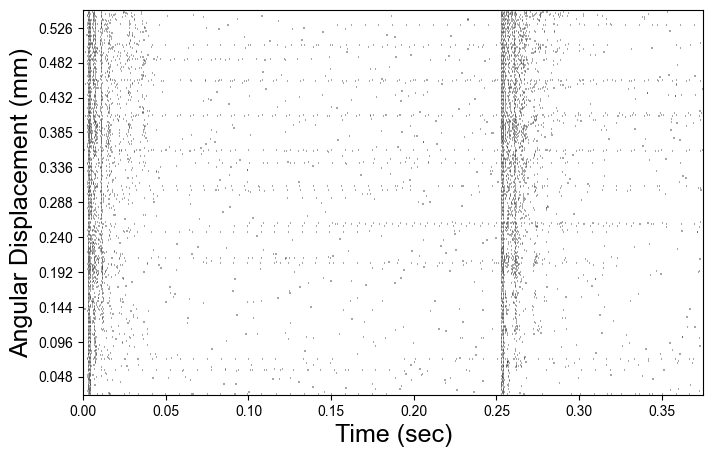

In [9]:


plt.rcParams['font.family'] = 'Arial'

trial_spike_times = []
for block_id in blocks_to_analyze:
    data = Step_triangles_Trials[block_id][channel_index]
    time = np.arange(len(data)) / SR
    peaks, properties = find_peaks(data, height=0.025, distance=int(SR * 0.0005))
    trial_spike_times.append(time[peaks])
trial_spike_times = np.array(trial_spike_times, dtype=object)

n_trials = len(blocks_to_analyze)
n_amps = len(step_windows)
gap_rows = 1
window_dur = step_windows[0][1] - step_windows[0][0]

raster_data = []
line_offsets = []
group_centers = []

for a_idx, (t_start, t_end) in enumerate(step_windows):
    base = a_idx * (n_trials + gap_rows)
    for tr in range(n_trials):
        sp = trial_spike_times[tr]
        mask = (sp >= t_start) & (sp < t_end)
        sp_rel = sp[mask] - t_start
        raster_data.append(sp_rel)
        line_offsets.append(base + tr)
    group_centers.append(base + (n_trials - 1) / 2)


plt.figure(figsize=(8, 5))
plt.eventplot(
    raster_data,
    lineoffsets=line_offsets,
    linelengths=0.8,
    linewidths=0.5,
    colors='black'
)

plt.xlim(0, window_dur)
plt.xlabel("Time (sec)", fontsize=18)
plt.ylabel("Angular Displacement (mm)", fontsize=18)

plt.yticks(group_centers, [f"{amp:.3f}" for amp in amplitudes], fontsize=10)
plt.ylim(-2, n_amps * (n_trials + gap_rows))



plt.show()


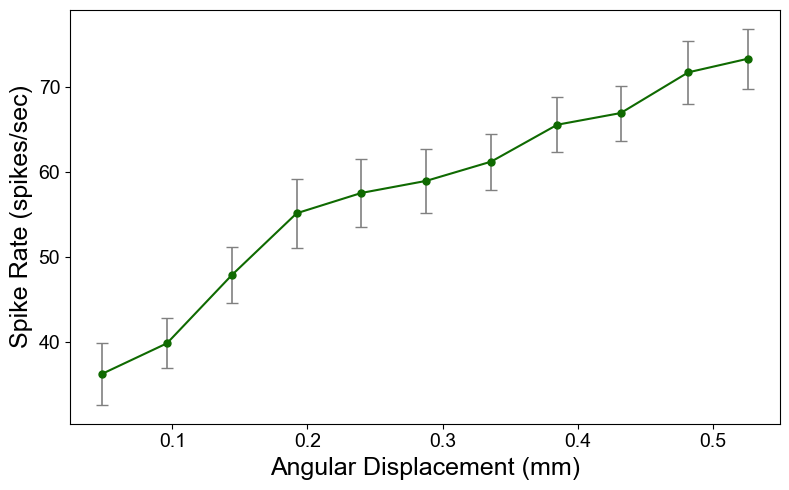

In [6]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

SR = 40000  


amplitudes = np.array([0.048, 0.096, 0.144, 0.192, 0.240,
                       0.288, 0.336, 0.385, 0.432, 0.482, 0.526])

step_windows = [
    (1.50, 1.875),
    (2.00, 2.375),
    (2.50, 2.875),
    (3.00, 3.375),
    (3.50, 3.875),
    (4.00, 4.375),
    (4.50, 4.875),
    (5.00, 5.375),
    (5.50, 5.875),
    (6.00, 6.375),
    (6.50, 6.875)
]


blocks_to_analyze = ['block_60', 'block_1', 'block_2', 'block_3', 'block_4','block_5', 'block_6', 'block_7', 'block_8', 'block_9',
                     'block_10', 'block_11', 'block_12', 'block_13', 'block_14','block_15', 'block_16', 'block_17', 'block_18', 'block_19',
                     'block_20', 'block_21', 'block_22', 'block_23', 'block_24','block_25', 'block_26', 'block_27', 'block_28', 'block_29',
                     'block_30', 'block_31', 'block_32', 'block_33', 'block_34','block_35', 'block_36', 'block_37', 'block_38', 'block_39',
                     'block_40', 'block_41', 'block_42', 'block_43', 'block_44','block_45', 'block_46', 'block_47', 'block_48', 'block_49',
                     'block_50', 'block_51', 'block_52', 'block_53', 'block_54','block_55', 'block_56', 'block_57', 'block_58', 'block_59']
channel_index = 0


all_spike_rates = []

for block_id in blocks_to_analyze:
    data = Step_triangles_Trials[block_id][channel_index]
    time = np.arange(len(data)) / SR

    
    peaks, properties = find_peaks(data, height=0.025, distance=int(SR * 0.0005))
    spike_times = time[peaks]

   
    spike_rates = []
    for (t_start, t_end) in step_windows:
        spikes_in_window = np.sum((spike_times >= t_start) & (spike_times < t_end))
        rate = spikes_in_window / (t_end - t_start)
        spike_rates.append(rate)
   
    all_spike_rates.append(spike_rates)


all_spike_rates = np.array(all_spike_rates)


mean_rates = np.mean(all_spike_rates, axis=0)
sem_rates = np.std(all_spike_rates, axis=0, ddof=1) / np.sqrt(all_spike_rates.shape[0])

amplitude_mm = amplitudes 


plt.rcParams['font.family'] = 'Arial'

plt.figure(figsize=(8, 5))
plt.errorbar(
    amplitude_mm, mean_rates,
    yerr=sem_rates,
    fmt='o-', color='#0f6a01',
    ecolor='gray', elinewidth=1.2, capsize=4, capthick=1,
    markersize=5, linewidth=1.5
)

ax = plt.gca()
plt.xlabel("Angular Displacement (mm)", fontsize=18)
plt.ylabel("Spike Rate (spikes/sec)", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()


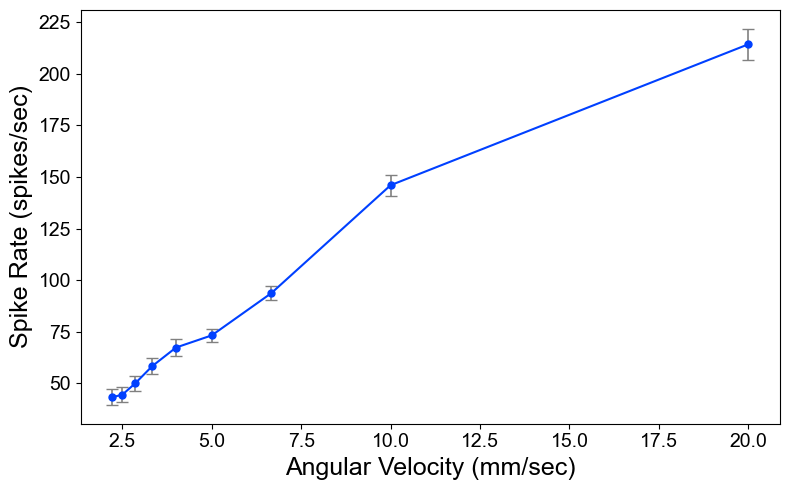

In [7]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

SR = 40000  


stim_velocity = np.array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

triangle_windows = [
    (8.00, 8.45),
    (8.75, 9.15),
    (9.50, 9.85),
    (10.25, 10.55),
    (11.00, 11.25),
    (11.75, 11.95),
    (12.50, 12.65),
    (13.25, 13.35),
    (14.00, 14.05),
]


blocks_to_analyze = ['block_60', 'block_1', 'block_2', 'block_3', 'block_4','block_5', 'block_6', 'block_7', 'block_8', 'block_9',
                     'block_10', 'block_11', 'block_12', 'block_13', 'block_14','block_15', 'block_16', 'block_17', 'block_18', 'block_19',
                     'block_20', 'block_21', 'block_22', 'block_23', 'block_24','block_25', 'block_26', 'block_27', 'block_28', 'block_29',
                     'block_30', 'block_31', 'block_32', 'block_33', 'block_34','block_35', 'block_36', 'block_37', 'block_38', 'block_39',
                     'block_40', 'block_41', 'block_42', 'block_43', 'block_44','block_45', 'block_46', 'block_47', 'block_48', 'block_49',
                     'block_50', 'block_51', 'block_52', 'block_53', 'block_54','block_55', 'block_56', 'block_57', 'block_58', 'block_59']
channel_index = 0

all_spike_rates = []

for block_id in blocks_to_analyze:
    data = Step_triangles_Trials[block_id][channel_index]
    time = np.arange(len(data)) / SR

   
    peaks, properties = find_peaks(data, height=0.025, distance=int(SR * 0.0005))
    spike_times = time[peaks]

    spike_rates = []
    for (t_start, t_end) in triangle_windows:
        spikes_in_window = np.sum((spike_times >= t_start) & (spike_times < t_end))
        rate = spikes_in_window / (t_end - t_start)
        spike_rates.append(rate)
    all_spike_rates.append(spike_rates)


all_spike_rates = np.array(all_spike_rates)


mean_rates = np.mean(all_spike_rates, axis=0)
sem_rates = np.std(all_spike_rates, axis=0, ddof=1) / np.sqrt(all_spike_rates.shape[0])


triangle_durations = np.array([t_end - t_start for t_start, t_end in triangle_windows])
half_time = triangle_durations / 2
stim_velocity_mm = stim_velocity / half_time


plt.rcParams['font.family'] = 'Arial'

plt.figure(figsize=(8, 5))
plt.errorbar(
    stim_velocity_mm, mean_rates,
    yerr=sem_rates,
    fmt='o-', color='#0040ff',        
    ecolor='gray', elinewidth=1.2, capsize=4, capthick=1,
    markersize=5, linewidth=1.5
)

ax = plt.gca()
plt.xlabel("Angular Velocity (mm/sec)", fontsize=18)
plt.ylabel("Spike Rate (spikes/sec)", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()


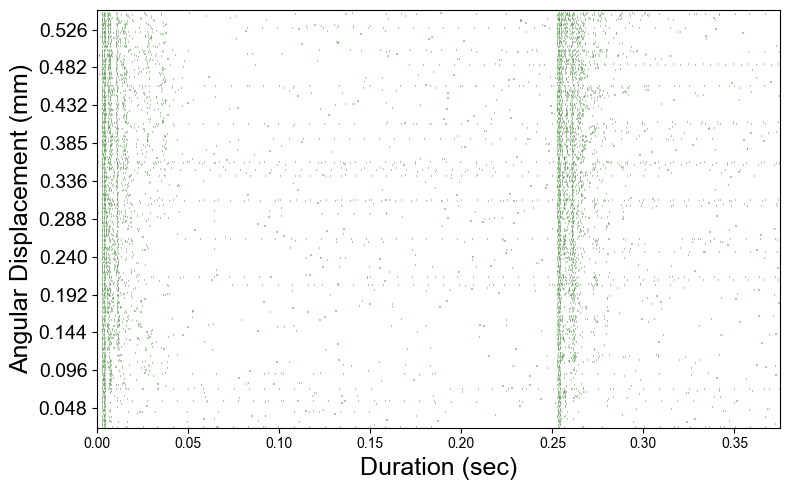

In [8]:

plt.rcParams['font.family'] = 'Arial'

trial_spike_times = []
for block_id in blocks_to_analyze:
    data = Step_triangles_Trials[block_id][channel_index]
    time = np.arange(len(data)) / SR
    peaks, properties = find_peaks(data, height=0.025, distance=int(SR * 0.0005))
    trial_spike_times.append(time[peaks])
trial_spike_times = np.array(trial_spike_times, dtype=object)

n_trials = len(blocks_to_analyze)
n_amps = len(step_windows)
gap_rows = 1
window_dur = step_windows[0][1] - step_windows[0][0]

raster_data = []
line_offsets = []
group_centers = []

for a_idx, (t_start, t_end) in enumerate(step_windows):
    base = a_idx * (n_trials + gap_rows)
    for tr in range(n_trials):
        sp = trial_spike_times[tr]
        mask = (sp >= t_start) & (sp < t_end)
        sp_rel = sp[mask] - t_start
        raster_data.append(sp_rel)
        line_offsets.append(base + tr)
    group_centers.append(base + (n_trials - 1) / 2)

plt.figure(figsize=(8, 5))
plt.eventplot(
    raster_data,
    lineoffsets=line_offsets,
    linelengths=0.8,
    linewidths=0.5,
    colors='#0f6a01'   
)

plt.xlim(0, window_dur)
plt.xlabel("Duration (sec)", fontsize=18)
plt.ylabel("Angular Displacement (mm)", fontsize=18)

plt.yticks(group_centers, [f"{amp:.3f}" for amp in amplitudes], fontsize=14)
plt.ylim(-2, n_amps * (n_trials + gap_rows))

plt.tight_layout()
plt.show()


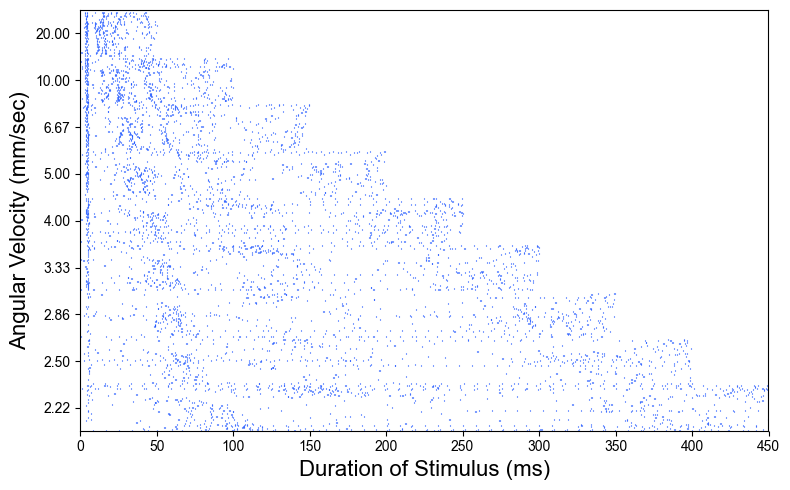

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

SR = 40000
num_trials_to_plot = 60

all_window_spikes = [] 
max_window_ms = 0.0

for (t_start, t_end) in triangle_windows:
    window_spikes = []
    window_ms = (t_end - t_start) * 1000.0
    if window_ms > max_window_ms:
        max_window_ms = window_ms

    for block_id in blocks_to_analyze[:num_trials_to_plot]:
        data = Step_triangles_Trials[block_id][channel_index]
        time = np.arange(len(data)) / SR
        peaks, _ = find_peaks(data, height=0.025, distance=int(SR * 0.0005))
        spike_times = time[peaks]

    
        spikes_in_window = spike_times[(spike_times >= t_start) & (spike_times < t_end)]
        aligned_spikes = (spikes_in_window - t_start) * 1000.0
        window_spikes.append(aligned_spikes)

    all_window_spikes.append(window_spikes)


plt.rcParams['font.family'] = 'Arial'
fig, ax = plt.subplots(figsize=(8, 5))

trial_spacing = 1.0       
group_gap = 2.0           

current_offset = 0.0
group_centers = []

for window_spikes in all_window_spikes:
    offsets = np.arange(len(window_spikes)) * trial_spacing + current_offset
    ax.eventplot(
        window_spikes,
        lineoffsets=offsets,
        linelengths=0.8,       
        linewidths=0.8,         
        colors='#0040ff'
    )
   
    group_centers.append(current_offset + (len(window_spikes) - 1) * trial_spacing / 2.0)
   
    current_offset += len(window_spikes) * trial_spacing + group_gap


triangle_durations = np.array([t_end - t_start for t_start, t_end in triangle_windows])
half_time = triangle_durations / 2.0
stim_velocity_mm = (stim_velocity / half_time)  


ax.set_xlim(0.0, max_window_ms)
ax.set_xmargin(0.0)          
plt.margins(x=0)             
ax.set_xlabel("Duration of Stimulus (ms)", fontsize=16)


ax.set_ylim(-0.5, current_offset - group_gap + 0.5)
ax.set_yticks(group_centers)
ax.set_yticklabels([f"{v:.2f}" for v in stim_velocity_mm], fontsize=10)
ax.set_ylabel("Angular Velocity (mm/sec)", fontsize=16)


ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)


plt.tight_layout()
plt.show()


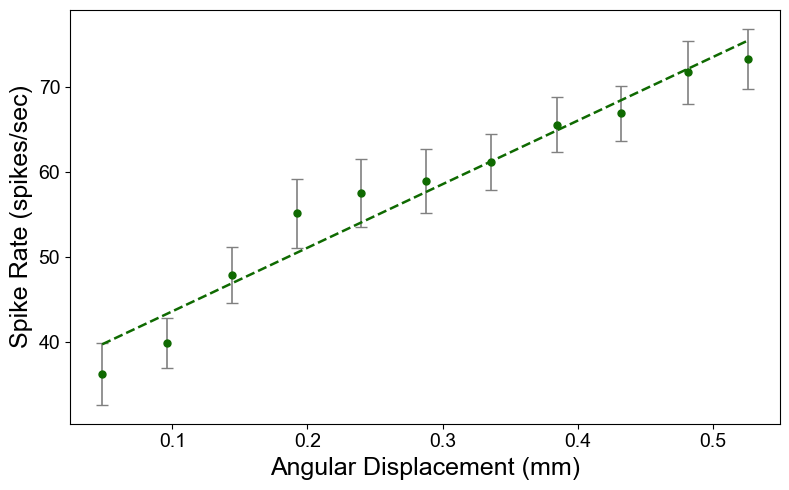

Slope: 74.9234
Intercept: 36.1041
R² = 0.9544


In [10]:
from scipy.signal import find_peaks
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt

SR = 40000  # sampling rate

# --- define amplitudes and their corresponding stimulus times ---
amplitudes = np.array([0.048, 0.096, 0.144, 0.192, 0.240,
                       0.288, 0.336, 0.385, 0.432, 0.482, 0.526])

step_windows = [
    (1.50, 1.875),
    (2.00, 2.375),
    (2.50, 2.875),
    (3.00, 3.375),
    (3.50, 3.875),
    (4.00, 4.375),
    (4.50, 4.875),
    (5.00, 5.375),
    (5.50, 5.875),
    (6.00, 6.375),
    (6.50, 6.875)
]


blocks_to_analyze = ['block_60', 'block_1', 'block_2', 'block_3', 'block_4','block_5', 'block_6', 'block_7', 'block_8', 'block_9',
                     'block_10', 'block_11', 'block_12', 'block_13', 'block_14','block_15', 'block_16', 'block_17', 'block_18', 'block_19',
                     'block_20', 'block_21', 'block_22', 'block_23', 'block_24','block_25', 'block_26', 'block_27', 'block_28', 'block_29',
                     'block_30', 'block_31', 'block_32', 'block_33', 'block_34','block_35', 'block_36', 'block_37', 'block_38', 'block_39',
                     'block_40', 'block_41', 'block_42', 'block_43', 'block_44','block_45', 'block_46', 'block_47', 'block_48', 'block_49',
                     'block_50', 'block_51', 'block_52', 'block_53', 'block_54','block_55', 'block_56', 'block_57', 'block_58', 'block_59']
channel_index = 0


all_spike_rates = []

for block_id in blocks_to_analyze:
    data = Step_triangles_Trials[block_id][channel_index]
    time = np.arange(len(data)) / SR

    
    peaks, properties = find_peaks(data, height=0.025, distance=int(SR * 0.0005))
    spike_times = time[peaks]

    
    spike_rates = []
    for (t_start, t_end) in step_windows:
        spikes_in_window = np.sum((spike_times >= t_start) & (spike_times < t_end))
        rate = spikes_in_window / (t_end - t_start)
        spike_rates.append(rate)
   
    all_spike_rates.append(spike_rates)


all_spike_rates = np.array(all_spike_rates)


mean_rates = np.mean(all_spike_rates, axis=0)
sem_rates = np.std(all_spike_rates, axis=0, ddof=1) / np.sqrt(all_spike_rates.shape[0])

amplitude_mm = amplitudes 


slope, intercept, r_value, p_value, std_err = linregress(amplitude_mm, mean_rates)
r_squared = r_value**2


x_fit = np.linspace(min(amplitude_mm), max(amplitude_mm), 200)
y_fit = slope * x_fit + intercept


plt.rcParams['font.family'] = 'Arial'

plt.figure(figsize=(8, 5))
plt.errorbar(
    amplitude_mm, mean_rates,
    yerr=sem_rates,
    fmt='o', color='#0f6a01',
    ecolor='gray', elinewidth=1.2, capsize=4, capthick=1,
    markersize=5, linewidth=1.5
)


plt.plot(x_fit, y_fit, linestyle='--', color='#0f6a01', linewidth=1.8)

ax = plt.gca()
plt.xlabel("Angular Displacement (mm)", fontsize=18)
plt.ylabel("Spike Rate (spikes/sec)", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()


print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R² = {r_squared:.4f}")


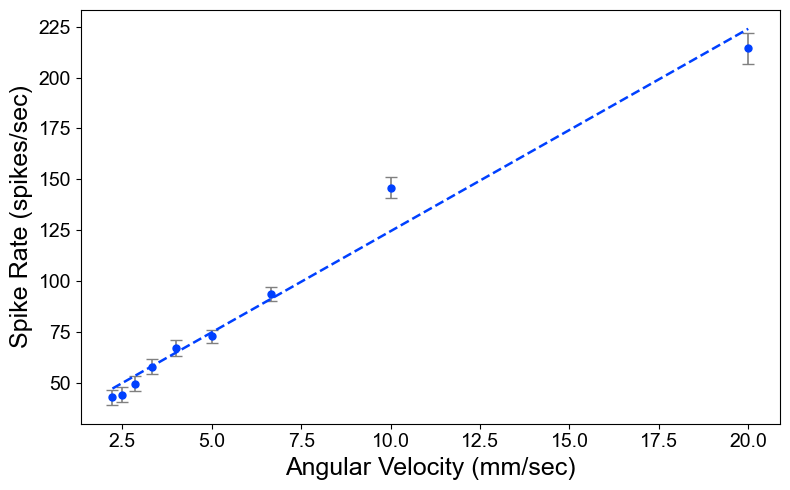

Slope: 9.9241
Intercept: 25.4015
R² = 0.9761


In [11]:
from scipy.signal import find_peaks
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt

SR = 40000  


stim_velocity = np.array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

triangle_windows = [
    (8.00, 8.45),
    (8.75, 9.15),
    (9.50, 9.85),
    (10.25, 10.55),
    (11.00, 11.25),
    (11.75, 11.95),
    (12.50, 12.65),
    (13.25, 13.35),
    (14.00, 14.05),
]


blocks_to_analyze = ['block_60', 'block_1', 'block_2', 'block_3', 'block_4','block_5', 'block_6', 'block_7', 'block_8', 'block_9',
                     'block_10', 'block_11', 'block_12', 'block_13', 'block_14','block_15', 'block_16', 'block_17', 'block_18', 'block_19',
                     'block_20', 'block_21', 'block_22', 'block_23', 'block_24','block_25', 'block_26', 'block_27', 'block_28', 'block_29',
                     'block_30', 'block_31', 'block_32', 'block_33', 'block_34','block_35', 'block_36', 'block_37', 'block_38', 'block_39',
                     'block_40', 'block_41', 'block_42', 'block_43', 'block_44','block_45', 'block_46', 'block_47', 'block_48', 'block_49',
                     'block_50', 'block_51', 'block_52', 'block_53', 'block_54','block_55', 'block_56', 'block_57', 'block_58', 'block_59']
channel_index = 0


all_spike_rates = []

for block_id in blocks_to_analyze:
    data = Step_triangles_Trials[block_id][channel_index]
    time = np.arange(len(data)) / SR

    
    peaks, properties = find_peaks(data, height=0.025, distance=int(SR * 0.0005))
    spike_times = time[peaks]

    spike_rates = []
    for (t_start, t_end) in triangle_windows:
        spikes_in_window = np.sum((spike_times >= t_start) & (spike_times < t_end))
        rate = spikes_in_window / (t_end - t_start)
        spike_rates.append(rate)
    all_spike_rates.append(spike_rates)


all_spike_rates = np.array(all_spike_rates)


mean_rates = np.mean(all_spike_rates, axis=0)
sem_rates = np.std(all_spike_rates, axis=0, ddof=1) / np.sqrt(all_spike_rates.shape[0])


triangle_durations = np.array([t_end - t_start for t_start, t_end in triangle_windows])
half_time = triangle_durations / 2
stim_velocity_mm = stim_velocity / half_time


slope, intercept, r_value, p_value, std_err = linregress(stim_velocity_mm, mean_rates)
r_squared = r_value ** 2


x_fit = np.linspace(min(stim_velocity_mm), max(stim_velocity_mm), 200)
y_fit = slope * x_fit + intercept


plt.rcParams['font.family'] = 'Arial'

plt.figure(figsize=(8, 5))
plt.errorbar(
    stim_velocity_mm, mean_rates,
    yerr=sem_rates,
    fmt='o', color='#0040ff',        
    ecolor='gray', elinewidth=1.2, capsize=4, capthick=1,
    markersize=5, linewidth=1.5
)


plt.plot(x_fit, y_fit, linestyle='--', color='#0040ff', linewidth=1.8)

ax = plt.gca()
plt.xlabel("Angular Velocity (mm/sec)", fontsize=18)
plt.ylabel("Spike Rate (spikes/sec)", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()


print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R² = {r_squared:.4f}")
